# 04 - Evaluation

Test the two models from `03_training` on the test set,
and use Grad-CAM to see what the models look at. The cropped model is the final model (chosen in `03_training`).

## 1. Imports

In [18]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, models, transforms
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

## 2. Device and paths

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

PROCESSED_DIR = Path("..") / "data" / "processed"
FULL_DIR = PROCESSED_DIR / "full"
CROPPED_DIR = PROCESSED_DIR / "cropped"
MODEL_DIR = Path("..") / "outputs" / "models"

device

device(type='cuda')

## 3. Load the models

Same setup as in `03_training`: a ResNet18 with a last layer of 4 outputs.
Then the saved weights of the best epoch are loaded into it.
`eval()` puts the model in evaluation mode, because we only predict here, we don't train.

In [6]:
full_model = models.resnet18()
full_model.fc = nn.Linear(full_model.fc.in_features, 4)
full_model.load_state_dict(torch.load(MODEL_DIR / "resnet18_full.pt", map_location=device))
full_model = full_model.to(device).eval()

cropped_model = models.resnet18()
cropped_model.fc = nn.Linear(cropped_model.fc.in_features, 4)
cropped_model.load_state_dict(torch.load(MODEL_DIR / "resnet18_cropped.pt", map_location=device))
cropped_model = cropped_model.to(device).eval()

## 4. Test data

Same transform as the validation set in `03_training`, so no augmentation.
`shuffle=False` keeps the predictions in the same order as the labels.

In [7]:
weights = models.ResNet18_Weights.DEFAULT
MEAN = weights.transforms().mean
STD = weights.transforms().std

eval_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

full_test_data = datasets.ImageFolder(FULL_DIR / "test", transform=eval_transform)
cropped_test_data = datasets.ImageFolder(CROPPED_DIR / "test", transform=eval_transform)

full_test_loader = DataLoader(full_test_data, batch_size=32, shuffle=False)
cropped_test_loader = DataLoader(cropped_test_data, batch_size=32, shuffle=False)

labels = np.array(cropped_test_data.targets)
classes = cropped_test_data.classes

len(full_test_data), len(cropped_test_data)

(1467, 1467)

## 5. Predictions

For every test image the model gives 4 scores. `softmax` turns them into probabilities that add up to 1,
and the class with the highest probability is the prediction. The probabilities are kept for the error analysis.

In [8]:
full_probs = np.zeros((len(full_test_data), 4))
start = 0
with torch.no_grad():
    for images, _ in full_test_loader:
        outputs = full_model(images.to(device))
        full_probs[start:start + len(images)] = torch.softmax(outputs, dim=1).cpu().numpy()
        start += len(images)

cropped_probs = np.zeros((len(cropped_test_data), 4))
start = 0
with torch.no_grad():
    for images, _ in cropped_test_loader:
        outputs = cropped_model(images.to(device))
        cropped_probs[start:start + len(images)] = torch.softmax(outputs, dim=1).cpu().numpy()
        start += len(images)

full_preds = full_probs.argmax(axis=1)
cropped_preds = cropped_probs.argmax(axis=1)

## 6. Scores

### 6.1 Accuracy

In [9]:
pd.Series({
    "full": (full_preds == labels).mean(),
    "cropped": (cropped_preds == labels).mean(),
}, name="test accuracy").round(4)

full       0.9250
cropped    0.9298
Name: test accuracy, dtype: float64

### 6.2 Per class

- **Precision:** of all images the model called this class, how many were right.
- **Recall:** of all images that really are this class, how many the model found. For tumors this is the one that matters most: a missed tumor is worse than a false alarm.

In [10]:
cropped_report = pd.DataFrame(classification_report(labels, cropped_preds, target_names=classes, output_dict=True)).T
full_report = pd.DataFrame(classification_report(labels, full_preds, target_names=classes, output_dict=True)).T

pd.concat([full_report.loc[classes, ["precision", "recall"]], cropped_report.loc[classes, ["precision", "recall"]]], axis=1, keys=["full", "cropped"]).round(3)

full          cropped       
           precision recall precision recall
glioma         0.994  0.850     0.976  0.861
meningioma     0.924  0.877     0.953  0.879
notumor        0.819  0.993     0.801  1.000
pituitary      0.964  0.992     0.990  0.992

### 6.3 Conclusions

- On the test set the cropped model gets 93.0% and the full model 92.5%. That's a lot lower than the 98.6% on validation.
- The big problem: notumor has a recall of 100%, but a precision of only 80%. The model calls too many images "notumor",
  and most of those are actually glioma or meningioma. So it misses tumors, which is the worst kind of mistake here.
- Pituitary is almost perfect (99%).
- Cropped is a bit better than full again, but the difference is small (7 images).
- The validation set came from the original training folder, the test set from the original test folder. The gap between them
  suggests the test images are different from what the model saw during training. Next step: look at the mistakes to find out why.

## 7. Error analysis

### 7.1 Confusion matrix

Rows are the real class, columns what the model predicted. Everything outside the diagonal is a mistake.

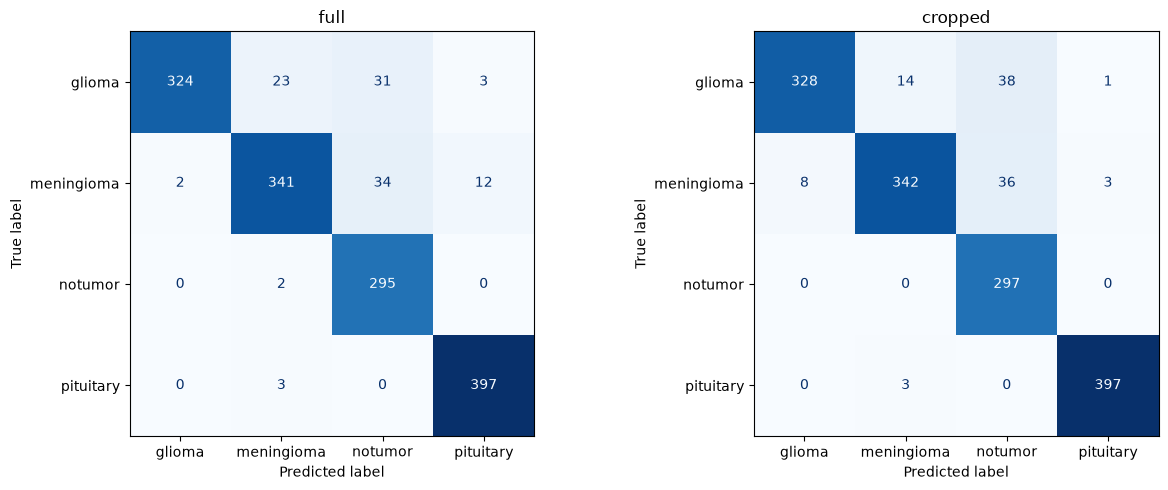

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ConfusionMatrixDisplay(confusion_matrix(labels, full_preds), display_labels=classes).plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("full")
ConfusionMatrixDisplay(confusion_matrix(labels, cropped_preds), display_labels=classes).plot(ax=axes[1], colorbar=False, cmap="Blues")
axes[1].set_title("cropped")
plt.tight_layout()
plt.show()

### 7.2 Missed tumors

Twelve random tumor images that the cropped model called "notumor", with how sure the model was.

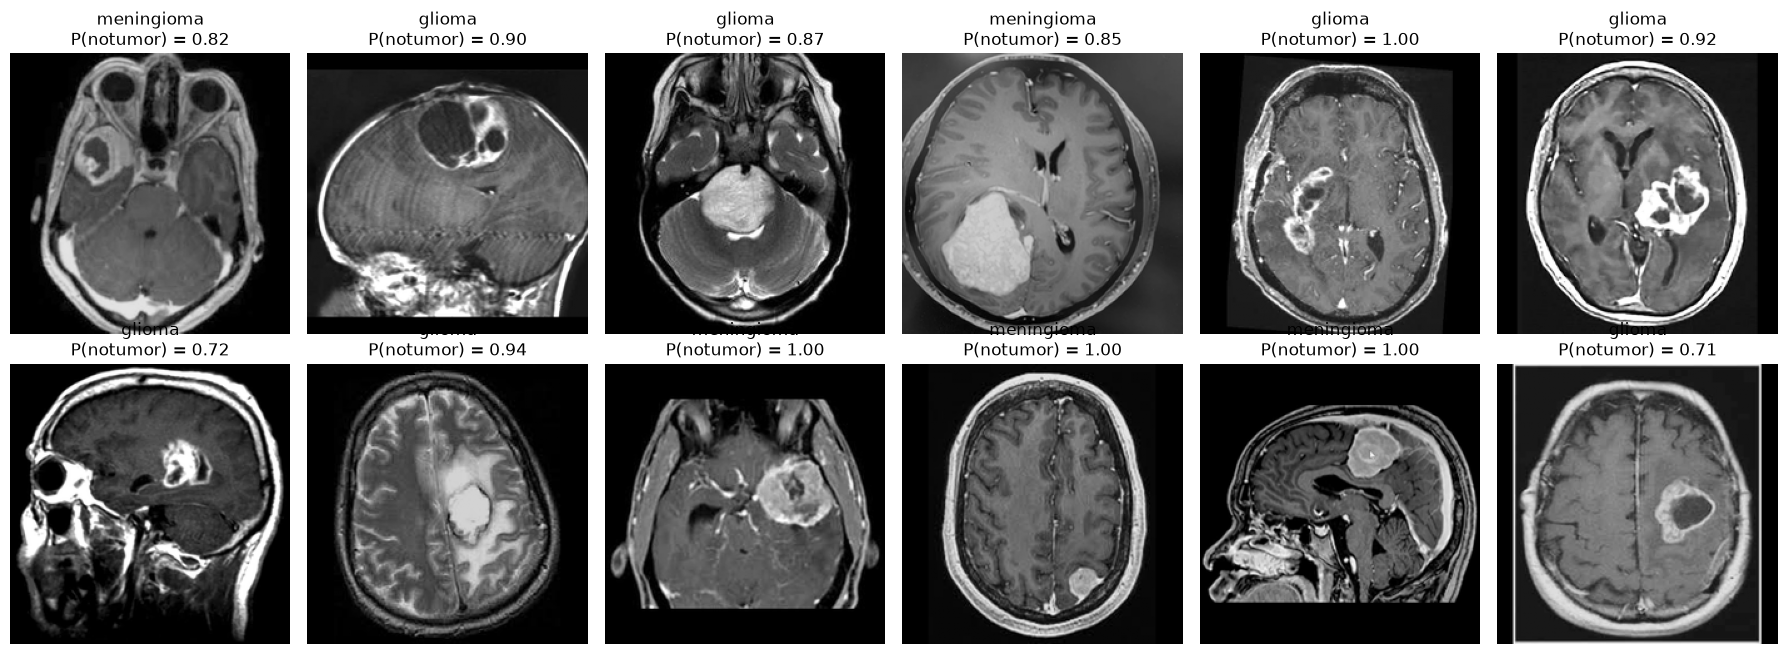

74

In [14]:
notumor = classes.index("notumor")
test_paths = [Path(p) for p, _ in cropped_test_data.samples]
missed = np.where((labels != notumor) & (cropped_preds == notumor))[0]
examples = np.random.default_rng(0).choice(missed, size=12, replace=False)

fig, axes = plt.subplots(2, 6, figsize=(18, 6.5))
for ax, i in zip(axes.flat, examples):
    ax.imshow(Image.open(test_paths[i]), cmap="gray", vmin=0, vmax=255)
    ax.set_title(f"{classes[labels[i]]}\nP(notumor) = {cropped_probs[i, notumor]:.2f}")
    ax.axis("off")
plt.tight_layout()
plt.show()

len(missed)

### 7.3 Is it the source?

In `01_eda`, almost all glioma, meningioma and pituitary images were exactly 512x512, and almost no notumor images.
So the original size tells us roughly which source an image comes from. Here the test accuracy is split by original size.

In [15]:
splits = pd.read_csv(PROCESSED_DIR / "splits.csv")
source_of = dict(zip(splits["file"], splits["source"]))

test = pd.DataFrame({
    "label": [classes[l] for l in labels],
    "correct": cropped_preds == labels,
    "called_notumor": cropped_preds == notumor,
})
test["is_512"] = [Image.open(source_of[p.name]).size == (512, 512) for p in test_paths]

test.groupby(["label", "is_512"]).agg(
    images=("correct", "size"),
    accuracy=("correct", "mean"),
    called_notumor=("called_notumor", "mean"),
).round(3)

images  accuracy  called_notumor
label      is_512                                  
glioma     False       63     0.206           0.603
           True       318     0.991           0.000
meningioma False      106     0.594           0.330
           True       283     0.986           0.004
notumor    False      294     1.000           1.000
           True         3     1.000           1.000
pituitary  False        8     1.000           0.000
           True       392     0.992           0.000

### 7.4 Conclusions

- Most mistakes (74 of 103) are tumors called "notumor". The model is often very sure about them: about two thirds have P(notumor) above 0.9.
- The table shows why. Tumor images that are 512x512 (the main source) are almost always right (99%).
  Tumor images with another size are often wrong: only 21% of those gliomas and 59% of those meningiomas are right.
- In the training set, all gliomas are 512x512. So the model never saw a glioma from another source,
  while almost all notumor images come from other sources. It learned "looks like the other source = notumor".
- Cropping, padding and equal brightness were not enough to hide the source. The images still look different (scanner, scan type,
  some even look like CT scans), and the model picks that up.
- This is the shortcut learning I was worried about in `01_eda`. The model works well on images that look like its training data,
  but it would not be safe on scans from a new hospital.

## 8. Grad-CAM

### 8.1 How it works

Grad-CAM shows which parts of the image made the model choose its prediction.
The last convolution layer of ResNet18 gives 512 small maps of 7x7, each one reacting to a different pattern.
The gradient tells how much each map matters for the predicted class. A weighted sum of the maps gives one 7x7 heatmap,
which is scaled up to 224x224 and laid over the image. Red = important for the prediction, blue = not important.

The examples: 2 correct images per class, and 4 tumors that were called "notumor". Each image is shown for both models.

In [19]:
rng = np.random.default_rng(1)
correct_examples = [rng.choice(np.where((labels == c) & (cropped_preds == c))[0]) for c in range(4) for _ in range(2)]
cam_examples = np.array(correct_examples + list(rng.choice(missed, size=4, replace=False)))

cams = {"full": np.zeros((len(cam_examples), 224, 224)), "cropped": np.zeros((len(cam_examples), 224, 224))}

for name, model, data, preds in [("full", full_model, full_test_data, full_preds), ("cropped", cropped_model, cropped_test_data, cropped_preds)]:
    feature_extractor = nn.Sequential(*list(model.children())[:-2])
    for k, i in enumerate(cam_examples):
        image = data[i][0].unsqueeze(0).to(device)

        features = feature_extractor(image)
        features.retain_grad()
        scores = model.fc(torch.flatten(model.avgpool(features), 1))
        scores[0, preds[i]].backward()

        map_weights = features.grad.mean(dim=(2, 3), keepdim=True)
        cam = torch.relu((map_weights * features).sum(dim=1, keepdim=True))
        cam = F.interpolate(cam, size=(224, 224), mode="bilinear")[0, 0].detach().cpu().numpy()
        cams[name][k] = cam / (cam.max() + 1e-8)

### 8.2 Heatmaps

Each pair of rows shows the same 6 images: first the full model, then the cropped model. The title is "real class -> prediction".

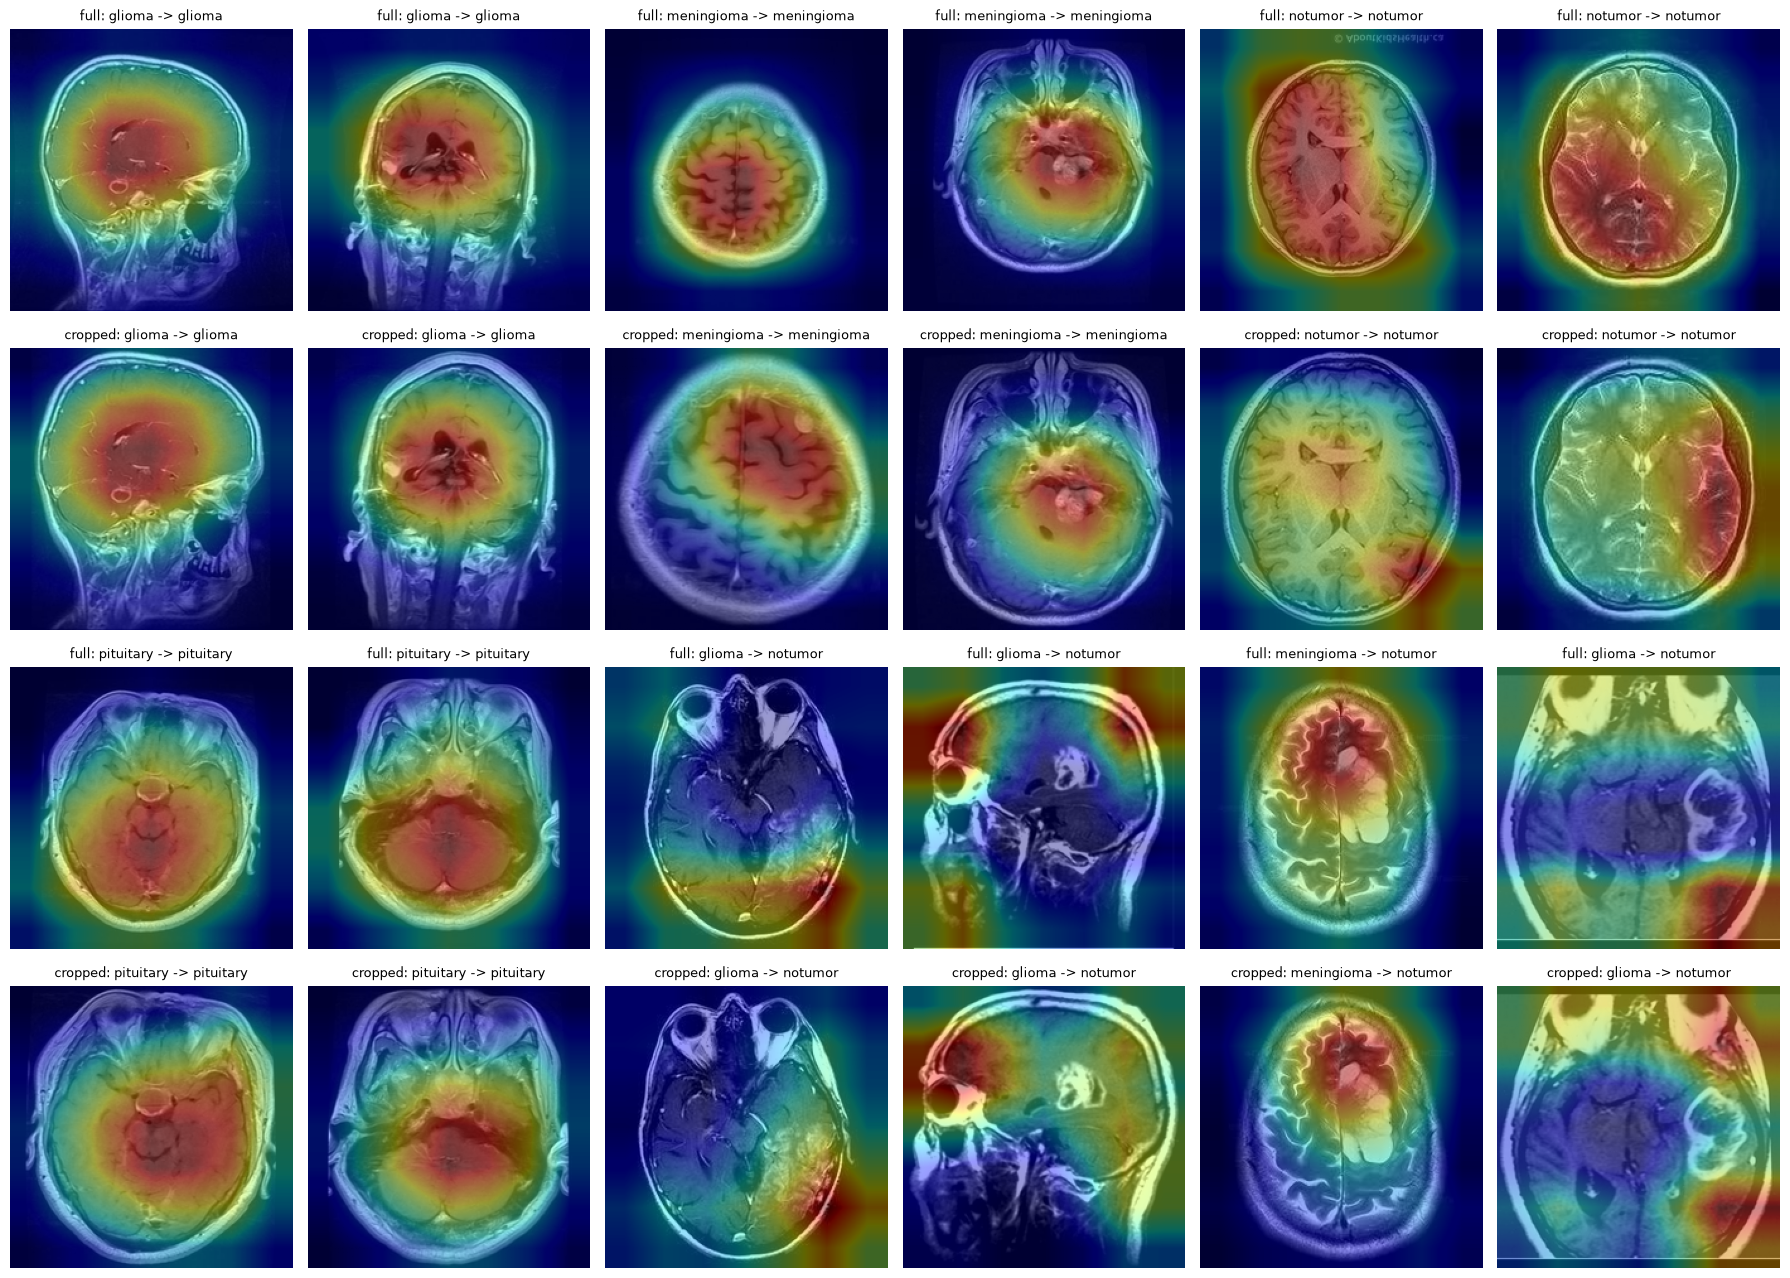

In [20]:
fig, axes = plt.subplots(4, 6, figsize=(18, 13))
for k, i in enumerate(cam_examples):
    row = (k // 6) * 2
    col = k % 6
    for offset, name, data, preds in [(0, "full", full_test_data, full_preds), (1, "cropped", cropped_test_data, cropped_preds)]:
        ax = axes[row + offset, col]
        ax.imshow(Image.open(data.samples[i][0]), cmap="gray", vmin=0, vmax=255)
        ax.imshow(cams[name][k], cmap="jet", alpha=0.4)
        ax.set_title(f"{name}: {classes[labels[i]]} -> {classes[preds[i]]}", fontsize=9)
        ax.axis("off")
plt.tight_layout()
plt.show()

### 8.3 Conclusions

- For the correct tumor predictions the heatmap is mostly in the middle of the brain, and for pituitary around the base of the brain,
  where the pituitary gland is. So there the model does look at the brain.
- For 3 of the 4 missed tumors (all gliomas) the heatmap is not on the tumor, even though the tumor is clearly visible.
  The red part sits at the edge or in a corner of the image, so the model decides "notumor" based on something outside the tumor.
- The missed meningioma is different: the model does look at the tumor, but still says "notumor".
- For the correct notumor predictions the cropped model also looks a lot at the edges. That fits with section 7:
  for notumor it seems to recognize the style of the source more than the brain itself.
- Full and cropped look at roughly the same places, so cropping did not change much here either.
- Grad-CAM is rough (a 7x7 grid scaled up) and these are only 12 images, so this is a hint, not proof. But it points the same way as section 7.